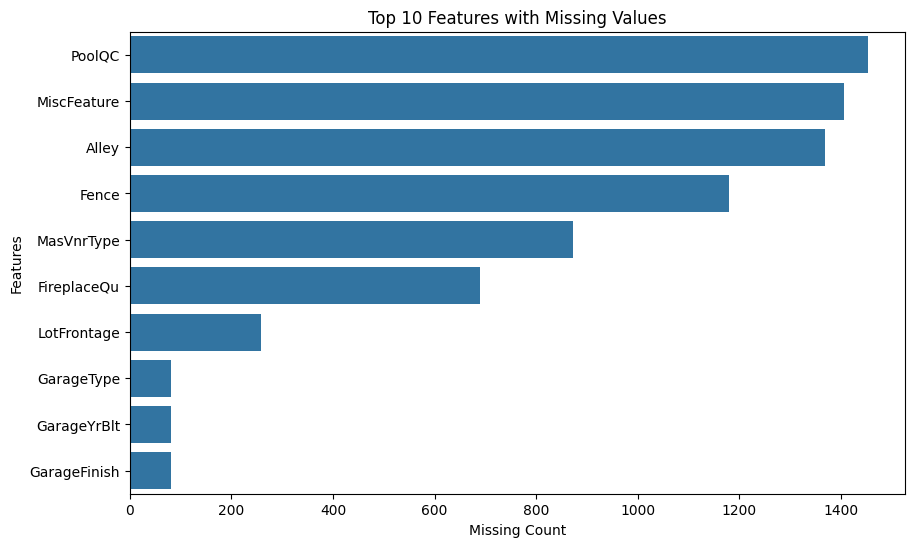

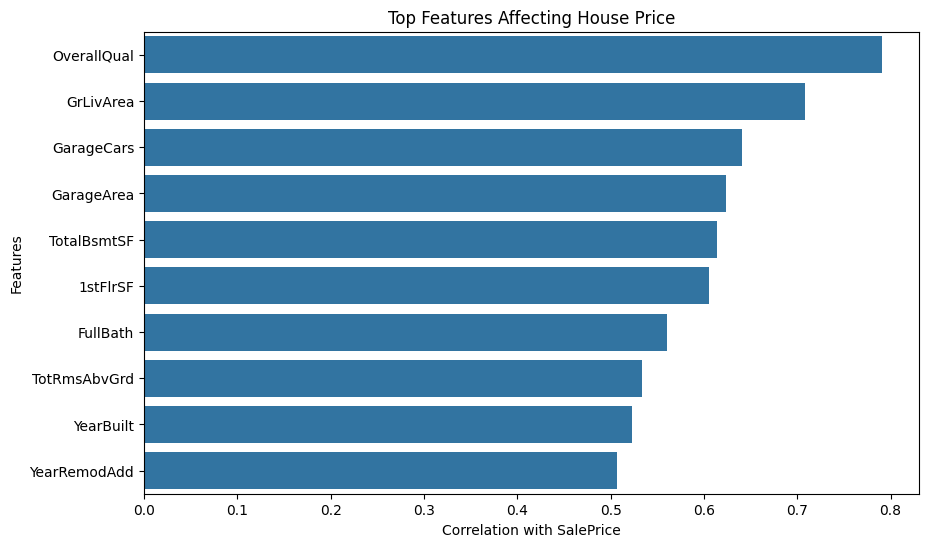

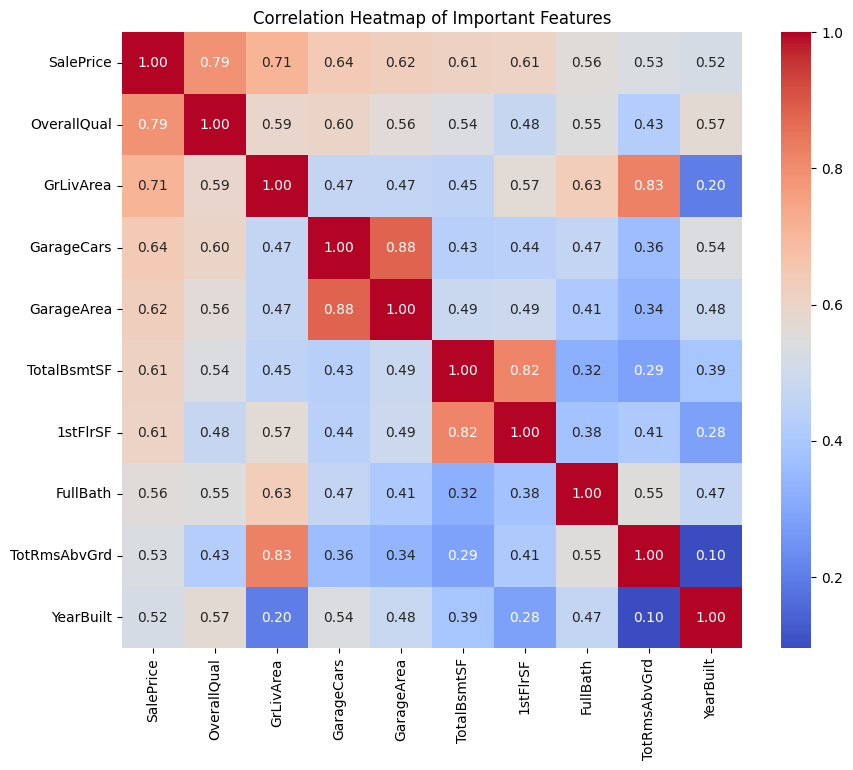

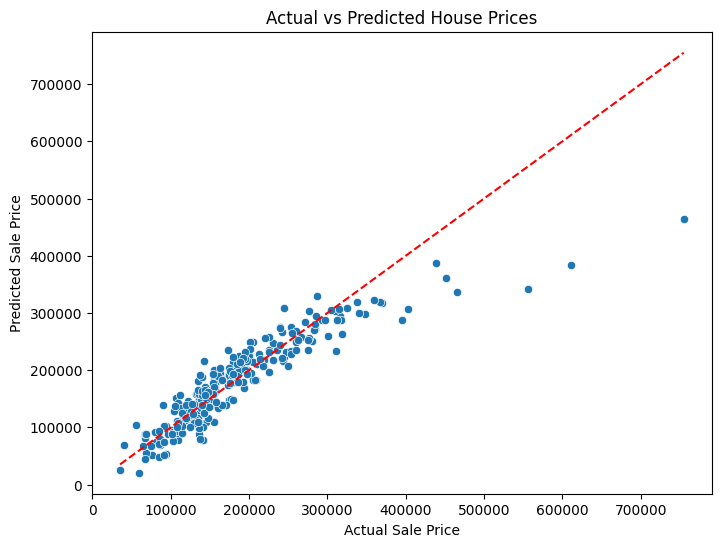

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge

train = pd.read_csv("train.csv")

missing = train.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x=missing.values[:10], y=missing.index[:10])
plt.title("Top 10 Features with Missing Values")
plt.xlabel("Missing Count")
plt.ylabel("Features")
plt.show()


corr = train.corr(numeric_only=True)

top_corr = corr["SalePrice"].sort_values(ascending=False)[1:11]

plt.figure(figsize=(10,6))
sns.barplot(x=top_corr.values, y=top_corr.index)
plt.title("Top Features Affecting House Price")
plt.xlabel("Correlation with SalePrice")
plt.ylabel("Features")
plt.show()



top_features = corr["SalePrice"].abs().sort_values(ascending=False).head(10).index

plt.figure(figsize=(10,8))
sns.heatmap(
    train[top_features].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Correlation Heatmap of Important Features")
plt.show()


X = train.drop("SalePrice", axis=1)
y = train["SalePrice"]


X = X.select_dtypes(include=['int64', 'float64'])


X = X.fillna(X.median())


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


model = Ridge(alpha=1.0)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

plt.figure(figsize=(8,6))
sns.scatterplot(x=y_test, y=y_pred)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("Actual Sale Price")
plt.ylabel("Predicted Sale Price")
plt.title("Actual vs Predicted House Prices")
plt.show()

In [ ]:

corr = train.corr(numeric_only=True)

top_corr = corr["SalePrice"].sort_values(ascending=False)[1:11]

plt.figure(figsize=(10,6))
sns.barplot(x=top_corr.values, y=top_corr.index)
plt.title("Top Features Affecting House Price")
plt.xlabel("Correlation with SalePrice")
plt.ylabel("Features")
plt.show()



top_features = corr["SalePrice"].abs().sort_values(ascending=False).head(10).index

plt.figure(figsize=(10,8))
sns.heatmap(
    train[top_features].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Correlation Heatmap of Important Features")
plt.show()


X = train.drop("SalePrice", axis=1)
y = train["SalePrice"]


X = X.select_dtypes(include=['int64', 'float64'])


X = X.fillna(X.median())


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


model = Ridge(alpha=1.0)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

plt.figure(figsize=(8,6))
sns.scatterplot(x=y_test, y=y_pred)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("Actual Sale Price")
plt.ylabel("Predicted Sale Price")
plt.title("Actual vs Predicted House Prices")
plt.show()